# Import Libraries

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report


# Load Dataset

In [35]:
df=pd.read_csv(r"C:\Users\Aamir choudhary\OneDrive\Desktop\seattle-weather.csv")

df.head()

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


# Dataset information:

In [36]:
df.shape


(1461, 6)

In [37]:
df.info()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1461 non-null   object 
 1   precipitation  1461 non-null   float64
 2   temp_max       1461 non-null   float64
 3   temp_min       1461 non-null   float64
 4   wind           1461 non-null   float64
 5   weather        1461 non-null   object 
dtypes: float64(4), object(2)
memory usage: 68.6+ KB


In [38]:
df.describe()

,precipitation,temp_max,temp_min,wind
count,1461.000000,1461.000000,1461.000000,1461.000000
mean,3.029432,16.439083,8.234771,3.241136
std,6.680194,7.349758,5.023004,1.437825
min,0.000000,-1.600000,-7.100000,0.400000
25%,0.000000,10.600000,4.400000,2.200000
50%,0.000000,15.600000,8.300000,3.000000
75%,2.800000,22.200000,12.200000,4.000000
max,55.900000,35.600000,18.300000,9.500000


# Missing Values Check

In [39]:
df.isnull().sum()

date             0
precipitation    0
temp_max         0
temp_min         0
wind             0
weather          0
dtype: int64

# Duplicate Values Check

In [40]:
df.duplicated().sum()

np.int64(0)

# EDA (Visualization)

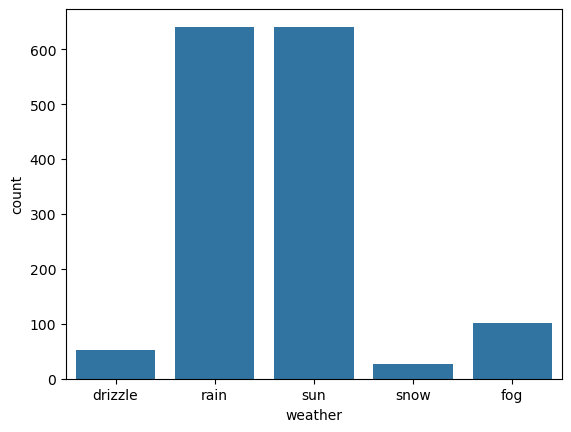

In [41]:
sns.countplot(
x='weather',
data=df
)

plt.show()

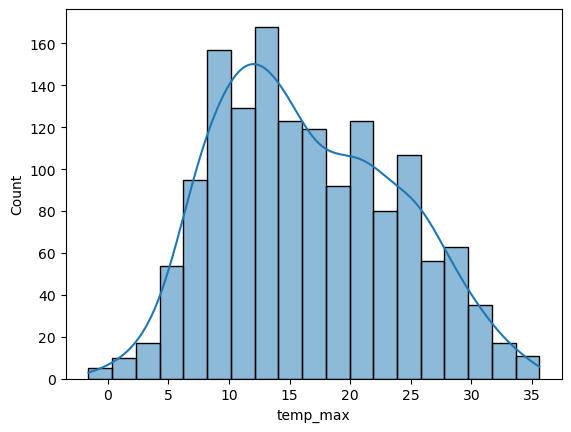

In [42]:
sns.histplot(
df["temp_max"],
kde=True
)

plt.show()

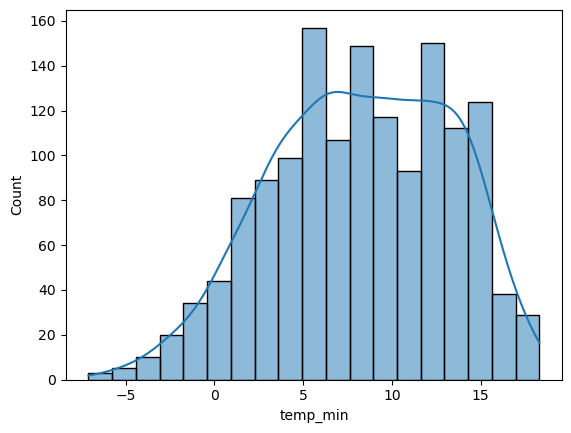

In [43]:
sns.histplot(
df["temp_min"],
kde=True
)

plt.show()

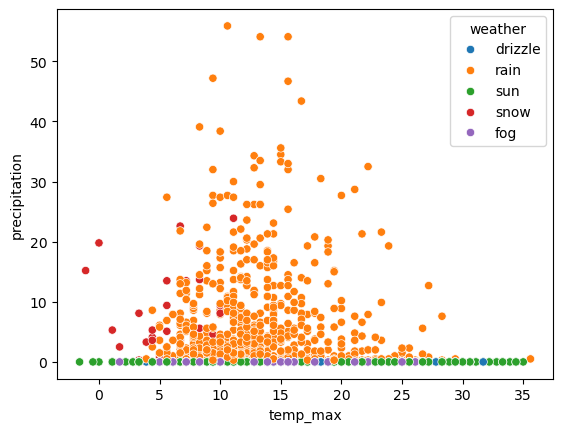

In [44]:
sns.scatterplot(
x="temp_max",
y="precipitation",
hue="weather",
data=df
)

plt.show()

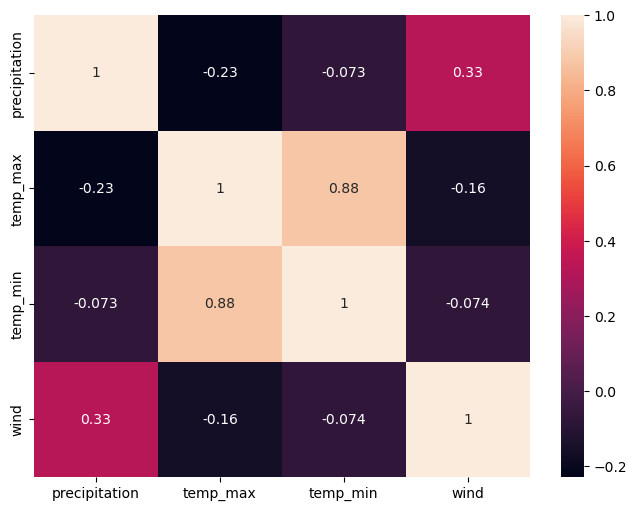

In [45]:
plt.figure(figsize=(8,6))

sns.heatmap(
df.corr(numeric_only=True),
annot=True
)

plt.show()

# Outlier Detection

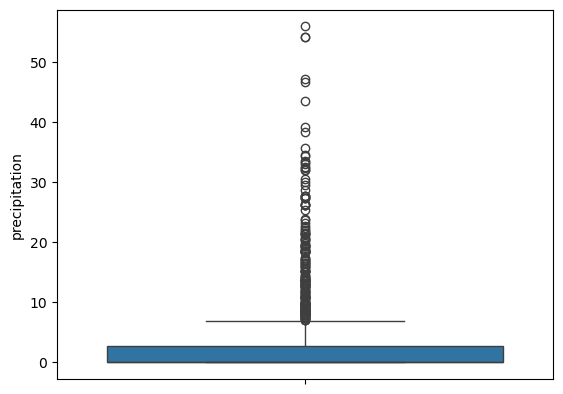

In [46]:
sns.boxplot(df["precipitation"])

plt.show()

# Remove using IQR:

In [47]:
Q1=df["precipitation"].quantile(.25)

Q3=df["precipitation"].quantile(.75)

IQR=Q3-Q1

lower=Q1-1.5*IQR

upper=Q3+1.5*IQR

df=df[
(df["precipitation"]>lower)&
(df["precipitation"]<upper)
]

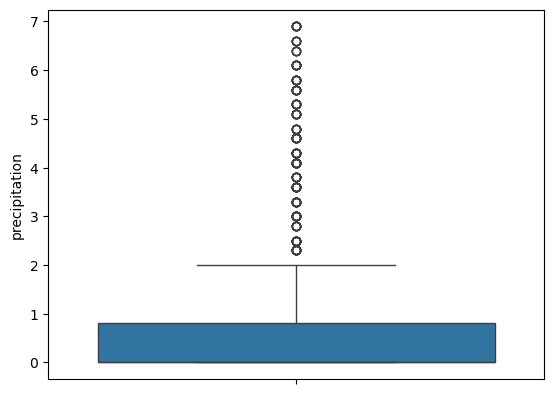

In [48]:
sns.boxplot(df["precipitation"])

plt.show()

# Drop Date Column

In [49]:
df.drop("date",axis=1,inplace=True)

# Label Encoding

In [50]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

df["weather"]=le.fit_transform(df["weather"])

In [51]:
df.head()

,precipitation,temp_max,temp_min,wind,weather
0,0.0,12.8,5.0,4.7,0
2,0.8,11.7,7.2,2.3,2
4,1.3,8.9,2.8,6.1,2
5,2.5,4.4,2.2,2.2,2
6,0.0,7.2,2.8,2.3,2


# Feature and Target

In [52]:
X=df.drop("weather",axis=1)

y=df["weather"]

# Train Test Split

In [53]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=\
train_test_split(
X,
y,
test_size=.20,
random_state=42
)

# Feature Scaling

In [54]:
from sklearn.preprocessing import StandardScaler

sc=StandardScaler()

X_train=sc.fit_transform(X_train)

X_test=sc.transform(X_test)

# KNN

In [55]:
from sklearn.neighbors import KNeighborsClassifier

knn=KNeighborsClassifier()

knn.fit(X_train,y_train)

pred2=knn.predict(X_test)

print("KNN Accuracy:",
      accuracy_score(y_test,pred2))

print(classification_report(y_test,pred2))


KNN Accuracy: 0.7410358565737052
              precision    recall  f1-score   support

           0       0.17      0.12      0.14         8
           1       0.14      0.09      0.11        22
           2       0.92      0.79      0.85        98
           3       1.00      0.67      0.80         3
           4       0.72      0.87      0.78       120

    accuracy                           0.74       251
   macro avg       0.59      0.51      0.54       251
weighted avg       0.73      0.74      0.73       251



# Naive Bayes

In [56]:
from sklearn.naive_bayes import GaussianNB

nb=GaussianNB()

nb.fit(X_train,y_train)

pred3=nb.predict(X_test)

accuracy_score(y_test,pred3)

0.8047808764940239

# Decision Tree

In [57]:
from sklearn.tree import DecisionTreeClassifier

dt=DecisionTreeClassifier()

dt.fit(X_train,y_train)

pred4=dt.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test,pred4))

print(classification_report(y_test,pred4))


Decision Tree Accuracy: 0.7131474103585658
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         8
           1       0.17      0.09      0.12        22
           2       0.90      0.87      0.89        98
           3       0.50      0.67      0.57         3
           4       0.73      0.75      0.74       120

    accuracy                           0.71       251
   macro avg       0.46      0.47      0.46       251
weighted avg       0.72      0.71      0.72       251



# Overfit / Underfit Check

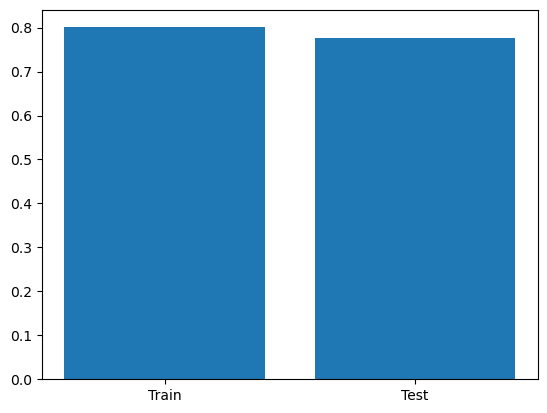

In [59]:
train_pred=svm.predict(X_train)

test_pred=svm.predict(X_test)

train_acc=accuracy_score(y_train,train_pred)

test_acc=accuracy_score(y_test,test_pred)

plt.bar(
["Train","Test"],
[train_acc,test_acc]
)

plt.show()